In [7]:
!pip install rebound -Uq

In [8]:
import rebound as rb
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [21]:
import rebound.horizons
rebound.horizons.SSL_CONTEXT = 'unverified'

Creamos la simulación y le agregamos:

* Sol
* Tierra
* Apophis

In [14]:
sim = rb.Simulation()
sim.add(m=1)
sim.add(m=0.1, x=1, vy=1)

In [15]:
ts = np.linspace(0, 10, 100)
rs = np.zeros((2, 100, 3))
vs = np.zeros((2, 100, 3))
rps = np.zeros((2, 100, 3))
vps = np.zeros((2, 100, 3))

for i,t in enumerate(ts):
    sim.integrate(t)
    rs[0,i] = sim.particles[0].xyz
    vs[0,i] = sim.particles[0].vxyz
    rs[1,i] = sim.particles[1].xyz
    vs[1,i] = sim.particles[1].vxyz
    sim.move_to_com()
    rps[0,i] = sim.particles[0].xyz
    vps[0,i] = sim.particles[0].vxyz
    rps[1,i] = sim.particles[1].xyz
    vps[1,i] = sim.particles[1].vxyz

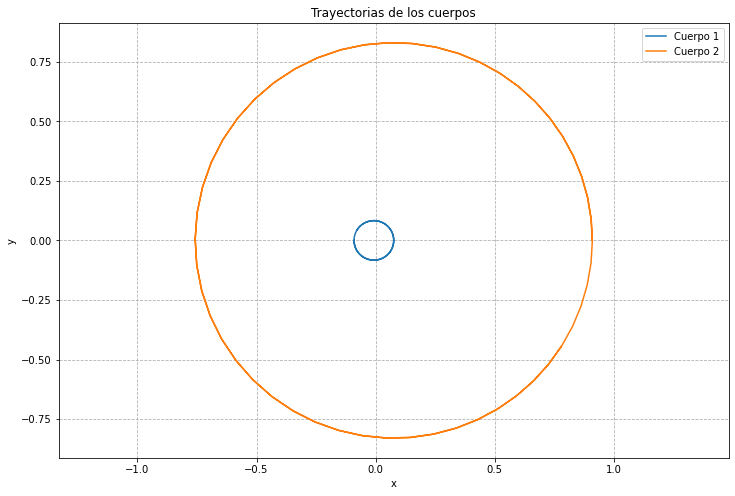

In [17]:
plt.figure(figsize=(6*2,4*2))
plt.plot(rps[0,:,0], rps[0,:,1], label='Cuerpo 1')
plt.plot(rps[1,:,0], rps[1,:,1], label='Cuerpo 2')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Trayectorias de los cuerpos')
plt.legend()
plt.axis('equal')
plt.grid(ls="--")

In [36]:
sim = rb.Simulation()
sim.add('Sun', date='2028-06-11')
sim.add('Earth', date='2028-06-11')
sim.add('Apophis', date='2028-06-11')

Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for 'Earth'... 
Found: Earth-Moon Barycenter (3) (chosen from query 'Earth')
Searching NASA Horizons for 'Apophis'... 
Found: 99942 Apophis (2004 MN4) 


/Users/danielvillada/opt/anaconda3/lib/python3.8/site-packages/rebound/horizons.py:184: RuntimeWarning: Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.
  warnings.warn("Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.", RuntimeWarning)


In [40]:
# ============================================
# 2. DEFINIR TIEMPO DE INTEGRACIÓN
# ============================================
ts = np.linspace(0, 1, 365)  # 0 a 1 año, 365 pasos

# ============================================
# 3. ARRAYS PARA ALMACENAR DATOS
# ============================================
n_cuerpos = 3  # Sun, Earth, Apophis
rs = np.zeros((n_cuerpos, len(ts), 3))   # posiciones
vs = np.zeros((n_cuerpos, len(ts), 3))   # velocidades
rps = np.zeros((n_cuerpos, len(ts), 3))  # posiciones (centro de masa)
vps = np.zeros((n_cuerpos, len(ts), 3))  # velocidades (centro de masa)

In [41]:
# ============================================
# 4. INTEGRAR Y GUARDAR DATOS
# ============================================
for i, t in enumerate(ts):
    sim.integrate(t)
    rs[0, i] = sim.particles[0].xyz
    vs[0, i] = sim.particles[0].vxyz
    rs[1, i] = sim.particles[1].xyz
    vs[1, i] = sim.particles[1].vxyz
    rs[2, i] = sim.particles[2].xyz
    vs[2, i] = sim.particles[2].vxyz
    
    sim.move_to_com()
    rps[0, i] = sim.particles[0].xyz
    vps[0, i] = sim.particles[0].vxyz
    rps[1, i] = sim.particles[1].xyz
    vps[1, i] = sim.particles[1].vxyz
    rps[2, i] = sim.particles[2].xyz
    vps[2, i] = sim.particles[2].vxyz


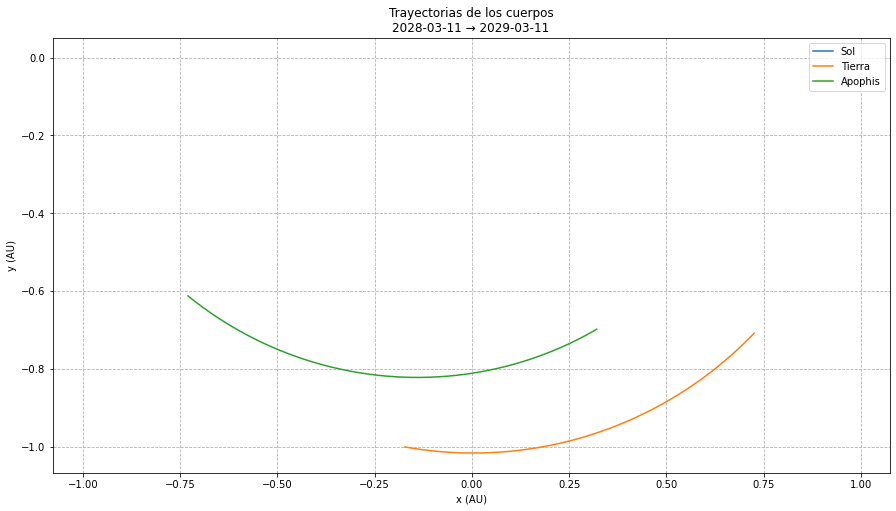

In [42]:
# ============================================
# 5. PLOTEAR TRAYECTORIAS
# ============================================
plt.figure(figsize=(6*2.5, 4*2))
plt.plot(rps[0, :, 0], rps[0, :, 1], label='Sol')
plt.plot(rps[1, :, 0], rps[1, :, 1], label='Tierra')
plt.plot(rps[2, :, 0], rps[2, :, 1], label='Apophis')
plt.xlabel('x (AU)')
plt.ylabel('y (AU)')
plt.title('Trayectorias de los cuerpos\n2028-03-11 → 2029-03-11')
plt.legend()
plt.axis('equal')
plt.grid(ls="--")
plt.show()

Fecha inicio: 2028-03-11
Fecha fin: 2029-03-11
Número de pasos: 366
Tiempo total: 0.9993 años
Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for 'Earth'... 
Found: Earth-Moon Barycenter (3) (chosen from query 'Earth')
Searching NASA Horizons for 'Apophis'... 
Found: 99942 Apophis (2004 MN4) 


/Users/danielvillada/opt/anaconda3/lib/python3.8/site-packages/rebound/horizons.py:184: RuntimeWarning: Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.
  warnings.warn("Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.", RuntimeWarning)


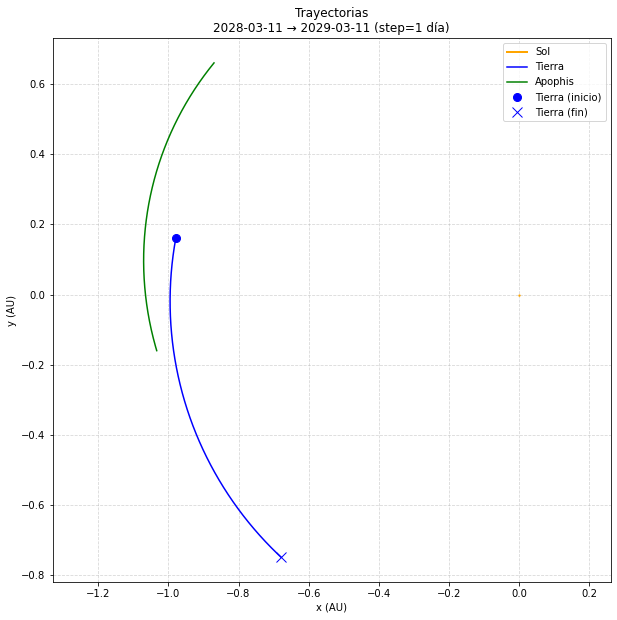

In [43]:
import rebound as rb
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# ============================================
# 1. DEFINIR FECHAS (start, end, step)
# ============================================
fecha_inicio = datetime(2028, 3, 11)
fecha_fin = datetime(2029, 3, 11)
step_dias = 1  # 1 día entre cada punto

# Crear array de fechas
fechas = []
fecha_actual = fecha_inicio
while fecha_actual <= fecha_fin:
    fechas.append(fecha_actual)
    fecha_actual += timedelta(days=step_dias)

# Convertir a tiempo relativo en AÑOS (REBOUND usa años como unidad)
ts = np.array([(f - fecha_inicio).days / 365.25 for f in fechas])

print(f"Fecha inicio: {fecha_inicio.date()}")
print(f"Fecha fin: {fecha_fin.date()}")
print(f"Número de pasos: {len(ts)}")
print(f"Tiempo total: {ts[-1]:.4f} años")

# ============================================
# 2. CREAR SIMULACIÓN
# ============================================
sim = rb.Simulation()
sim.add('Sun', date=fecha_inicio.strftime('%Y-%m-%d'))
sim.add('Earth', date=fecha_inicio.strftime('%Y-%m-%d'))
sim.add('Apophis', date=fecha_inicio.strftime('%Y-%m-%d'))

# ============================================
# 3. ARRAYS PARA ALMACENAR DATOS
# ============================================
n_cuerpos = 3
n_pasos = len(ts)
rs = np.zeros((n_cuerpos, n_pasos, 3))
vs = np.zeros((n_cuerpos, n_pasos, 3))

# ============================================
# 4. INTEGRAR Y GUARDAR DATOS
# ============================================
for i, t in enumerate(ts):
    sim.integrate(t)
    for j in range(n_cuerpos):
        rs[j, i] = sim.particles[j].xyz
        vs[j, i] = sim.particles[j].vxyz

# ============================================
# 5. PLOTEAR TRAYECTORIAS
# ============================================
plt.figure(figsize=(10, 10))
plt.plot(rs[0, :, 0], rs[0, :, 1], label='Sol', color='orange', linewidth=2)
plt.plot(rs[1, :, 0], rs[1, :, 1], label='Tierra', color='blue', linewidth=1.5)
plt.plot(rs[2, :, 0], rs[2, :, 1], label='Apophis', color='green', linewidth=1.5)

# Marcar inicio y fin de la Tierra
plt.plot(rs[1, 0, 0], rs[1, 0, 1], 'bo', markersize=8, label='Tierra (inicio)')
plt.plot(rs[1, -1, 0], rs[1, -1, 1], 'bx', markersize=10, label='Tierra (fin)')

plt.xlabel('x (AU)')
plt.ylabel('y (AU)')
plt.title(f'Trayectorias\n{fecha_inicio.date()} → {fecha_fin.date()} (step={step_dias} día)')
plt.legend()
plt.axis('equal')
plt.grid(ls="--", alpha=0.5)
plt.show()

Simulando 366 días
Tiempo final en unidades REBOUND: 6.2789 (debería ser ~2π = 6.2832)
Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for 'Earth'... 
Found: Earth-Moon Barycenter (3) (chosen from query 'Earth')
Searching NASA Horizons for 'Apophis'... 
Found: 99942 Apophis (2004 MN4) 


/Users/danielvillada/opt/anaconda3/lib/python3.8/site-packages/rebound/horizons.py:184: RuntimeWarning: Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.
  warnings.warn("Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.", RuntimeWarning)


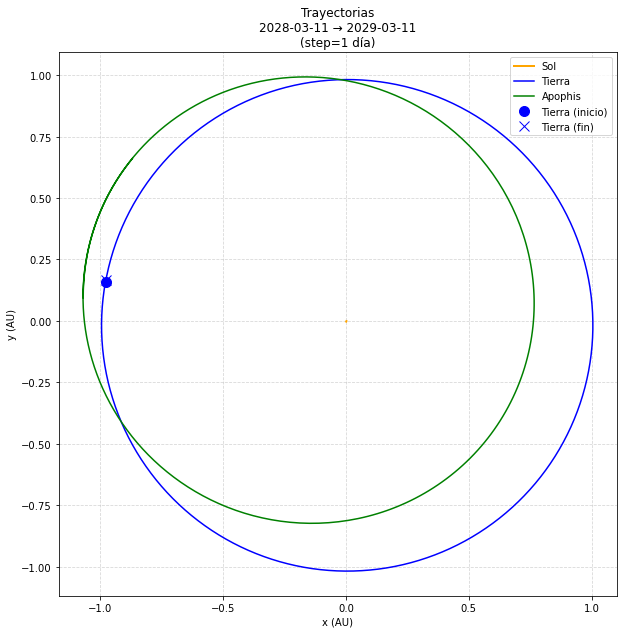


Distancia entre inicio y fin de la Tierra: 0.006577 AU
En kilómetros: 983861.59 km


In [44]:
import rebound as rb
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# ============================================
# 1. DEFINIR FECHAS
# ============================================
fecha_inicio = datetime(2028, 3, 11)
fecha_fin = datetime(2029, 3, 11)
step_dias = 1

n_dias = (fecha_fin - fecha_inicio).days + 1

# ⚠️ IMPORTANTE: Convertir días a unidades REBOUND (multiplicar por 2π/365.25)
ts = np.arange(0, n_dias) * (2 * np.pi / 365.25)

print(f"Simulando {n_dias} días")
print(f"Tiempo final en unidades REBOUND: {ts[-1]:.4f} (debería ser ~2π = {2*np.pi:.4f})")

# ============================================
# 2. CREAR SIMULACIÓN
# ============================================
sim = rb.Simulation()
sim.add('Sun', date=fecha_inicio.strftime('%Y-%m-%d'))
sim.add('Earth', date=fecha_inicio.strftime('%Y-%m-%d'))
sim.add('Apophis', date=fecha_inicio.strftime('%Y-%m-%d'))

# ============================================
# 3. ARRAYS PARA ALMACENAR DATOS
# ============================================
n_cuerpos = 3
rs = np.zeros((n_cuerpos, len(ts), 3))

# ============================================
# 4. INTEGRAR Y GUARDAR DATOS
# ============================================
for i, t in enumerate(ts):
    sim.integrate(t)
    for j in range(n_cuerpos):
        rs[j, i] = sim.particles[j].xyz

# ============================================
# 5. PLOTEAR TRAYECTORIAS
# ============================================
plt.figure(figsize=(10, 10))
plt.plot(rs[0, :, 0], rs[0, :, 1], label='Sol', color='orange', linewidth=2)
plt.plot(rs[1, :, 0], rs[1, :, 1], label='Tierra', color='blue', linewidth=1.5)
plt.plot(rs[2, :, 0], rs[2, :, 1], label='Apophis', color='green', linewidth=1.5)

# Marcar inicio y fin de la Tierra
plt.plot(rs[1, 0, 0], rs[1, 0, 1], 'bo', markersize=10, label='Tierra (inicio)')
plt.plot(rs[1, -1, 0], rs[1, -1, 1], 'bx', markersize=10, label='Tierra (fin)')

plt.xlabel('x (AU)')
plt.ylabel('y (AU)')
plt.title(f'Trayectorias\n{fecha_inicio.date()} → {fecha_fin.date()}\n(step={step_dias} día)')
plt.legend()
plt.axis('equal')
plt.grid(ls="--", alpha=0.5)
plt.show()

# ============================================
# 6. VERIFICAR QUE SE CERRÓ LA ÓRBITA
# ============================================
distancia = np.linalg.norm(rs[1, 0] - rs[1, -1])
print(f"\nDistancia entre inicio y fin de la Tierra: {distancia:.6f} AU")
print(f"En kilómetros: {distancia * 149_597_870.7:.2f} km")